In [1]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import h5py
import numpy as np

# ENA

In [9]:
from pyhdf.SD import SD, SDC

fn = '/data/ggong/MODIS/ENA/MAC06S0.A2017339.0400.002.2017350205953.hdf'
hdf = SD(fn, SDC.READ)

vars_to_check = [
    "Cloud_Effective_Radius_1621",
    "Cloud_Water_Path_1621",
    "Cloud_Phase_Optical_Properties",
    "cloud_top_temperature_1km",
    "Latitude",
    "Longitude"
]

for v in vars_to_check:
    sds = hdf.select(v)
    print(f"{v}: shape = {sds[:].shape}")

Cloud_Effective_Radius_1621: shape = (2040, 11)
Cloud_Water_Path_1621: shape = (2040, 11)
Cloud_Phase_Optical_Properties: shape = (2040, 11)
cloud_top_temperature_1km: shape = (2040, 11)
Latitude: shape = (408, 3)
Longitude: shape = (408, 3)


lat shape: (408, 3) lon shape: (408, 3)
Total points: 1224
Points inside ENA: 48


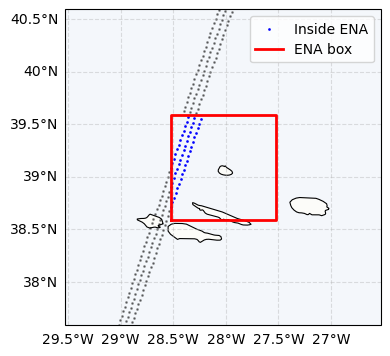

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyhdf.SD import SD, SDC

fn = '/data/ggong/MODIS/ENA/MAC06S0.A2017339.0400.002.2017350205953.hdf'

# ===== ENA box =====
ena_lat_min, ena_lat_max = 38.5916, 39.5916
ena_lon_min, ena_lon_max = -28.5257, -27.5257

hdf = SD(fn, SDC.READ)

lat = hdf.select("Latitude")[:].astype(float)
lon = hdf.select("Longitude")[:].astype(float)

# 经度统一到 -180~180
lon = ((lon + 180) % 360) - 180

# mask: inside ENA
mask_in = (
    (lat >= ena_lat_min) & (lat <= ena_lat_max) &
    (lon >= ena_lon_min) & (lon <= ena_lon_max)
)

print("lat shape:", lat.shape, "lon shape:", lon.shape)
print("Total points:", lat.size)
print("Points inside ENA:", int(mask_in.sum()))

# ===== plot =====
fig = plt.figure(figsize=(4, 4), dpi=100)
ax = plt.axes(projection=ccrs.PlateCarree())

# 给你画大一点范围，方便确认轨道到底在哪
ax.set_extent([ena_lon_min-1, ena_lon_max+1, ena_lat_min-1, ena_lat_max+1],
              crs=ccrs.PlateCarree())

ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.15)
ax.add_feature(cfeature.OCEAN, alpha=0.10)

gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4)
gl.top_labels = False
gl.right_labels = False

# ENA 外：黑
ax.scatter(lon[~mask_in].ravel(), lat[~mask_in].ravel(),
           s=1, color="black", alpha=0.4, transform=ccrs.PlateCarree())

# ENA 内：蓝
ax.scatter(lon[mask_in].ravel(), lat[mask_in].ravel(),
           s=1, color="blue", alpha=0.9, transform=ccrs.PlateCarree(),
           label="Inside ENA")

# ENA box：红框
ax.plot([ena_lon_min, ena_lon_max, ena_lon_max, ena_lon_min, ena_lon_min],
        [ena_lat_min, ena_lat_min, ena_lat_max, ena_lat_max, ena_lat_min],
        color="red", linewidth=2, transform=ccrs.PlateCarree(), label="ENA box")

plt.legend()
plt.tight_layout()
plt.show()

hdf.end()


In [12]:
import os
import glob
import numpy as np
import xarray as xr
from pyhdf.SD import SD, SDC

# ===== paths =====
IN_DIR = "/data/ggong/MODIS/ENA_5x5"
OUT_DIR = "/data/ggong/MODIS/ENA_nc_5x5"
os.makedirs(OUT_DIR, exist_ok=True)

# ===== ENA box =====
ena_lat_min, ena_lat_max = 36.5916, 41.5916
ena_lon_min, ena_lon_max = -30.5257, -25.5257

def read_scaled_nan(hdf, name, out_dtype=np.float32):
    sds = hdf.select(name)
    arr = sds.get().astype(out_dtype)
    a = sds.attributes()
    fill = a.get("_FillValue", None)
    scale = float(a.get("scale_factor", 1.0))
    offset = float(a.get("add_offset", 0.0))
    if fill is not None:
        arr = np.where(arr == fill, np.nan, arr)
    arr = arr * scale + offset
    return arr

def secs93_to_dt64ms(sec):
    epoch = np.datetime64("1993-01-01T00:00:00")
    ms = np.round(sec * 1000.0).astype(np.int64)
    return epoch + ms.astype("timedelta64[ms]")

def agg_1km_to_5km(x_1km, lat_shape):
    """
    把 1km (2030,11) 聚合到 5km geolocation (406,3)，默认 nanmean。
    兼容你 ENA subset 的 11 -> 3 (3-5-3) 特例。
    """
    n5, m5 = lat_shape
    n1, m1 = x_1km.shape
    if n1 != n5 * 5:
        raise ValueError(f"along-track mismatch: {x_1km.shape} vs {lat_shape}")

    x_along5 = np.nanmean(x_1km.reshape(n5, 5, m1), axis=1)  # (n5,m1)

    # ENA subset special case: 11 -> 3 via 3-5-3
    if (m1, m5) == (11, 3):
        g = [(0, 3), (3, 8), (8, 11)]
        return np.column_stack([np.nanmean(x_along5[:, a:b], axis=1) for a, b in g])

    edges = np.linspace(0, m1, m5 + 1).astype(int)
    return np.column_stack([np.nanmean(x_along5[:, edges[i]:edges[i+1]], axis=1) for i in range(m5)])

def refine_dup_time(time_ms):
    tu = np.unique(time_ms)
    dt = np.diff(tu) / np.timedelta64(1, "s")
    small = dt[(dt > 0) & (dt < 60)]
    if small.size == 0:
        return time_ms
    dt_ms = int(round(float(np.median(small)) * 1000))

    t = time_ms.astype("datetime64[ms]").copy()
    out = t.copy()
    i, n = 0, len(t)
    while i < n:
        j = i + 1
        while j < n and t[j] == t[i]:
            j += 1
        k = j - i
        if k > 1:
            offs = (np.arange(k) - (k - 1) / 2.0) * (dt_ms / k)
            out[i:j] = t[i] + np.round(offs).astype(np.int64).astype("timedelta64[ms]")
        i = j
    return out

def hdf_to_one_nc(fn, out_dir):
    base = os.path.splitext(os.path.basename(fn))[0]
    out_nc = os.path.join(out_dir, f"{base}_ENA_cloud_1621.nc")

    hdf = SD(fn, SDC.READ)

    # 5km geolocation/time
    lat = read_scaled_nan(hdf, "Latitude", np.float32)      # (406,3)
    lon = read_scaled_nan(hdf, "Longitude", np.float32)     # (406,3)
    lon = ((lon + 180) % 360) - 180  # 统一到 [-180,180]

    tsec = read_scaled_nan(hdf, "Scan_Start_Time", np.float64)  # (406,3)
    t1d = tsec[:, 0]
    good = np.isfinite(t1d) & (t1d >= 0)
    if good.sum() == 0:
        raise ValueError("no valid time")

    # 1km variables (2030,11)
    re1   = read_scaled_nan(hdf, "Cloud_Effective_Radius_1621", np.float32)
    reu1  = read_scaled_nan(hdf, "Cloud_Effective_Radius_Uncertainty_1621", np.float32)
    cod1  = read_scaled_nan(hdf, "Cloud_Optical_Thickness_1621", np.float32)
    codu1 = read_scaled_nan(hdf, "Cloud_Optical_Thickness_Uncertainty_1621", np.float32)
    cwp1  = read_scaled_nan(hdf, "Cloud_Water_Path_1621", np.float32)
    cwpu1 = read_scaled_nan(hdf, "Cloud_Water_Path_Uncertainty_1621", np.float32)
    ctt1  = read_scaled_nan(hdf, "cloud_top_temperature_1km", np.float32)

    # aggregate 1km -> 5km (406,3)
    re5   = agg_1km_to_5km(re1,   lat.shape)
    reu5  = agg_1km_to_5km(reu1,  lat.shape)
    cod5  = agg_1km_to_5km(cod1,  lat.shape)
    codu5 = agg_1km_to_5km(codu1, lat.shape)
    cwp5  = agg_1km_to_5km(cwp1,  lat.shape)
    cwpu5 = agg_1km_to_5km(cwpu1, lat.shape)
    ctt5  = agg_1km_to_5km(ctt1,  lat.shape)

    # apply good time rows
    lat = lat[good]
    lon = lon[good]
    re5, reu5 = re5[good], reu5[good]
    cod5, codu5 = cod5[good], codu5[good]
    cwp5, cwpu5 = cwp5[good], cwpu5[good]
    ctt5 = ctt5[good]
    time = secs93_to_dt64ms(t1d[good])

    # sort by time (within file)
    idx = np.argsort(time)
    time = time[idx]
    lat, lon = lat[idx], lon[idx]
    re5, reu5 = re5[idx], reu5[idx]
    cod5, codu5 = cod5[idx], codu5[idx]
    cwp5, cwpu5 = cwp5[idx], cwpu5[idx]
    ctt5 = ctt5[idx]

    # refine duplicate times
    time_ref = refine_dup_time(time)

    # flatten
    nx = lat.shape[1]
    t_flat = np.repeat(time_ref, nx)
    lat_f = lat.reshape(-1)
    lon_f = lon.reshape(-1)

    re_f   = re5.reshape(-1)
    reu_f  = reu5.reshape(-1)
    cod_f  = cod5.reshape(-1)
    codu_f = codu5.reshape(-1)
    cwp_f  = cwp5.reshape(-1)
    cwpu_f = cwpu5.reshape(-1)
    ctt_f  = ctt5.reshape(-1)

    in_box = (
        np.isfinite(lat_f) & np.isfinite(lon_f) &
        (lat_f >= ena_lat_min) & (lat_f <= ena_lat_max) &
        (lon_f >= ena_lon_min) & (lon_f <= ena_lon_max)
    )

    # write (empty or not)
    if in_box.sum() == 0:
        ds = xr.Dataset(
            data_vars=dict(
                re_1621=("obs", np.array([], dtype=np.float32)),
                re_1621_unc=("obs", np.array([], dtype=np.float32)),
                COD_1621=("obs", np.array([], dtype=np.float32)),
                COD_1621_unc=("obs", np.array([], dtype=np.float32)),
                CWP_1621=("obs", np.array([], dtype=np.float32)),
                CWP_1621_unc=("obs", np.array([], dtype=np.float32)),
                CTT=("obs", np.array([], dtype=np.float32)),
            ),
            coords=dict(
                time=("obs", np.array([], dtype="datetime64[ms]")),
                lat=("obs", np.array([], dtype=np.float32)),
                lon=("obs", np.array([], dtype=np.float32)),
            ),
            attrs=dict(
                source_file=fn,
                source="MAC06S0 1km vars aggregated to 5km geolocation, then filtered to ENA box",
                box=f"lat[{ena_lat_min},{ena_lat_max}], lon[{ena_lon_min},{ena_lon_max}]",
                note="No points inside ENA box for this granule.",
            )
        )
        ds.to_netcdf(out_nc)
        return out_nc, 0

    ds = xr.Dataset(
        data_vars=dict(
            re_1621=("obs", re_f[in_box].astype(np.float32)),
            re_1621_unc=("obs", reu_f[in_box].astype(np.float32)),
            COD_1621=("obs", cod_f[in_box].astype(np.float32)),
            COD_1621_unc=("obs", codu_f[in_box].astype(np.float32)),
            CWP_1621=("obs", cwp_f[in_box].astype(np.float32)),
            CWP_1621_unc=("obs", cwpu_f[in_box].astype(np.float32)),
            CTT=("obs", ctt_f[in_box].astype(np.float32)),
        ),
        coords=dict(
            time=("obs", t_flat[in_box]),
            lat=("obs",  lat_f[in_box].astype(np.float32)),
            lon=("obs",  lon_f[in_box].astype(np.float32)),
        ),
        attrs=dict(
            source_file=fn,
            source="MAC06S0 1km vars aggregated to 5km geolocation, then filtered to ENA box",
            box=f"lat[{ena_lat_min},{ena_lat_max}], lon[{ena_lon_min},{ena_lon_max}]",
            note="Duplicate times spread using median small dt within this granule.",
        )
    )

    # optional sort by time
    ds = ds.isel(obs=np.argsort(ds.time.values))

    ds.to_netcdf(out_nc)
    return out_nc, int(ds.sizes["obs"])

# ===== run all files =====
files = sorted(glob.glob(f"{IN_DIR}/*.hdf"))
print("N files:", len(files))

kept = skipped = 0
for fn in files:
    try:
        out_nc, nobs = hdf_to_one_nc(fn, OUT_DIR)
        kept += 1
        print(f"[OK] {os.path.basename(fn)} -> {os.path.basename(out_nc)}  obs={nobs}")
    except Exception as e:
        skipped += 1
        print(f"[SKIP] {os.path.basename(fn)}  {repr(e)}")

print("kept:", kept, "skipped:", skipped)
print("OUT_DIR:", OUT_DIR)

N files: 2716
[OK] MAC06S0.A2006156.0405.002.2017187151716.hdf -> MAC06S0.A2006156.0405.002.2017187151716_ENA_cloud_1621.nc  obs=287
[OK] MAC06S0.A2006156.1510.002.2017187202052.hdf -> MAC06S0.A2006156.1510.002.2017187202052_ENA_cloud_1621.nc  obs=340
[OK] MAC06S0.A2006158.1455.002.2017188055719.hdf -> MAC06S0.A2006158.1455.002.2017188055719_ENA_cloud_1621.nc  obs=62
[OK] MAC06S0.A2006158.1500.002.2017188055719.hdf -> MAC06S0.A2006158.1500.002.2017188055719_ENA_cloud_1621.nc  obs=278
[OK] MAC06S0.A2006163.1515.002.2017189062045.hdf -> MAC06S0.A2006163.1515.002.2017189062045_ENA_cloud_1621.nc  obs=28
[OK] MAC06S0.A2006165.0400.002.2017189164551.hdf -> MAC06S0.A2006165.0400.002.2017189164551_ENA_cloud_1621.nc  obs=339
[OK] MAC06S0.A2006165.1505.002.2017189203346.hdf -> MAC06S0.A2006165.1505.002.2017189203346_ENA_cloud_1621.nc  obs=339
[OK] MAC06S0.A2006167.0345.002.2017190083553.hdf -> MAC06S0.A2006167.0345.002.2017190083553_ENA_cloud_1621.nc  obs=13
[OK] MAC06S0.A2006167.0350.002.201719

In [14]:
import xarray as xr
import glob

nc_files = sorted(glob.glob("/data/ggong/MODIS/ENA_nc_5x5/*_ENA_cloud*.nc"))

def _pre(ds):
    # 保证 time 是 datetime64，并且只保留需要的变量（可选）
    # ds["time"] = ds["time"].astype("datetime64[ns]")  # 一般不需要，decode后已经是
    return ds

ds = xr.open_mfdataset(
    nc_files,
    combine="nested",        # 关键：不要用 by_coords
    concat_dim="obs",        # 沿 obs 维拼接
    preprocess=_pre,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    join="outer",            # 保险起见
    parallel=False,          # 有 dask 环境可 True
)

# 关键：拼完后按 time 排序
ds = ds.sortby("time")

print(ds)


<xarray.Dataset> Size: 24MB
Dimensions:       (obs: 541577)
Coordinates:
    time          (obs) datetime64[ns] 4MB dask.array<chunksize=(199,), meta=np.ndarray>
    lat           (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
    lon           (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
Dimensions without coordinates: obs
Data variables:
    re_1621       (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
    re_1621_unc   (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
    COD_1621      (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
    COD_1621_unc  (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
    CWP_1621      (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
    CWP_1621_unc  (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
    CTT           (obs) float32 2MB dask.array<chunksize=(199,), meta=np.ndarray>
Attributes:
    source_file:  /data/ggong/MODIS/

In [15]:
ds = ds.swap_dims({"obs": "time"})
ds = ds.sel(time=slice("2006-01-01", "2017-12-31"))
ds.to_netcdf('//data/ggong/MODIS/ENA_COD_merge_5x5.nc')

In [16]:
ds = xr.open_dataset('//data/ggong/MODIS/ENA_COD_merge_5x5.nc')

In [17]:
ds

<xarray.Dataset> Size: 24MB
Dimensions:       (time: 534273)
Coordinates:
  * time          (time) datetime64[ns] 4MB 2006-06-05T04:07:44.416000 ... 20...
    lat           (time) float32 2MB ...
    lon           (time) float32 2MB ...
Data variables:
    re_1621       (time) float32 2MB ...
    re_1621_unc   (time) float32 2MB ...
    COD_1621      (time) float32 2MB ...
    COD_1621_unc  (time) float32 2MB ...
    CWP_1621      (time) float32 2MB ...
    CWP_1621_unc  (time) float32 2MB ...
    CTT           (time) float32 2MB ...
Attributes:
    source_file:  /data/ggong/MODIS/ENA_5x5/MAC06S0.A2006156.0405.002.2017187...
    source:       MAC06S0 1km vars aggregated to 5km geolocation, then filter...
    box:          lat[36.5916,41.5916], lon[-30.5257,-25.5257]
    note:         Duplicate times spread using median small dt within this gr...

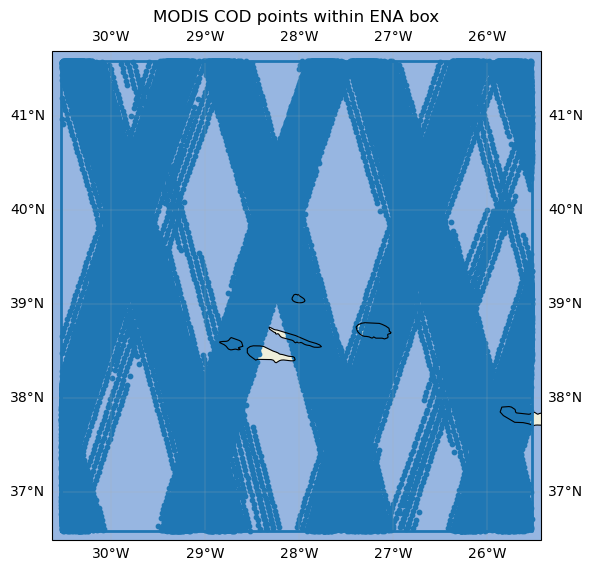

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 你的 ENA box（如果你前面已经有，就不用重复定义）
ena_lat_min, ena_lat_max = 36.5916, 41.5916
ena_lon_min, ena_lon_max = -30.5257, -25.5257

# 取数据（确保是 numpy array）
lon = ds["lon"].values
lat = ds["lat"].values

# 可选：过滤掉 NaN
m = np.isfinite(lon) & np.isfinite(lat)
lon = lon[m]
lat = lat[m]

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6, 6), dpi=100)
ax = plt.axes(projection=proj)

# 地图范围（稍微留点边）
pad = 0.1
ax.set_extent([ena_lon_min - pad, ena_lon_max + pad,
               ena_lat_min - pad, ena_lat_max + pad], crs=proj)

# 底图要素
ax.add_feature(cfeature.LAND, linewidth=0)
ax.add_feature(cfeature.OCEAN, linewidth=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.6)

# 画散点
ax.scatter(lon, lat, s=10, transform=proj)

# 画 ENA box（红框）
box_lon = [ena_lon_min, ena_lon_max, ena_lon_max, ena_lon_min, ena_lon_min]
box_lat = [ena_lat_min, ena_lat_min, ena_lat_max, ena_lat_max, ena_lat_min]
ax.plot(box_lon, box_lat, transform=proj, linewidth=2)

ax.set_title("MODIS COD points within ENA box")
plt.tight_layout()


# SGP

lat shape: (406, 3) lon shape: (406, 3)
Total points: 1218
Points inside SGP: 68


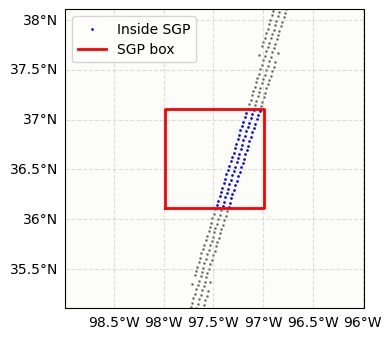

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyhdf.SD import SD, SDC

fn = '/data/ggong/MODIS/SGP/MAC06S0.A2016085.0835.002.2016090072105.hdf'

# ===== SGP box =====
sgp_lat_min, sgp_lat_max = 36.107322, 37.107322
sgp_lon_min, sgp_lon_max = -97.987643, -96.987643

hdf = SD(fn, SDC.READ)

lat = hdf.select("Latitude")[:].astype(float)
lon = hdf.select("Longitude")[:].astype(float)

# 经度统一到 -180~180
lon = ((lon + 180) % 360) - 180

# mask: inside SGP
mask_in = (
    (lat >= sgp_lat_min) & (lat <= sgp_lat_max) &
    (lon >= sgp_lon_min) & (lon <= sgp_lon_max)
)

print("lat shape:", lat.shape, "lon shape:", lon.shape)
print("Total points:", lat.size)
print("Points inside SGP:", int(mask_in.sum()))

# ===== plot =====
fig = plt.figure(figsize=(4, 4), dpi=100)
ax = plt.axes(projection=ccrs.PlateCarree())

# 范围稍微放大一点
ax.set_extent([sgp_lon_min-1, sgp_lon_max+1,
               sgp_lat_min-1, sgp_lat_max+1],
              crs=ccrs.PlateCarree())

ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.15)
ax.add_feature(cfeature.OCEAN, alpha=0.10)

gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4)
gl.top_labels = False
gl.right_labels = False

# SGP 外：黑
ax.scatter(lon[~mask_in].ravel(), lat[~mask_in].ravel(),
           s=1, color="black", alpha=0.4, transform=ccrs.PlateCarree())

# SGP 内：蓝
ax.scatter(lon[mask_in].ravel(), lat[mask_in].ravel(),
           s=1, color="blue", alpha=0.9, transform=ccrs.PlateCarree(),
           label="Inside SGP")

# SGP box：红框
ax.plot([sgp_lon_min, sgp_lon_max, sgp_lon_max, sgp_lon_min, sgp_lon_min],
        [sgp_lat_min, sgp_lat_min, sgp_lat_max, sgp_lat_max, sgp_lat_min],
        color="red", linewidth=2,
        transform=ccrs.PlateCarree(),
        label="SGP box")

plt.legend()
plt.tight_layout()
plt.show()

hdf.end()


In [19]:
import os
import glob
import numpy as np
import xarray as xr
from pyhdf.SD import SD, SDC

# ===== paths =====
IN_DIR = "/data/ggong/MODIS/SGP_5x5"          # <= 改成你的 SGP 输入目录
OUT_DIR = "/data/ggong/MODIS/SGP_nc_5x5"      # <= 改成你的 SGP 输出目录
os.makedirs(OUT_DIR, exist_ok=True)

# ===== SGP box =====
sgp_lat_min, sgp_lat_max = 34.107322, 39.107322
sgp_lon_min, sgp_lon_max = -99.987643, -94.987643

def read_scaled_nan(hdf, name, out_dtype=np.float32):
    sds = hdf.select(name)
    arr = sds.get().astype(out_dtype)
    a = sds.attributes()
    fill = a.get("_FillValue", None)
    scale = float(a.get("scale_factor", 1.0))
    offset = float(a.get("add_offset", 0.0))
    if fill is not None:
        arr = np.where(arr == fill, np.nan, arr)
    return arr * scale + offset

def secs93_to_dt64ms(sec):
    epoch = np.datetime64("1993-01-01T00:00:00")
    ms = np.round(sec * 1000.0).astype(np.int64)
    return epoch + ms.astype("timedelta64[ms]")

def agg_1km_to_5km(x_1km, lat_shape):
    n5, m5 = lat_shape
    n1, m1 = x_1km.shape
    if n1 != n5 * 5:
        raise ValueError(f"along-track mismatch: {x_1km.shape} vs {lat_shape}")

    x_along5 = np.nanmean(x_1km.reshape(n5, 5, m1), axis=1)  # (n5,m1)

    # subset special case: 11 -> 3 via 3-5-3
    if (m1, m5) == (11, 3):
        g = [(0, 3), (3, 8), (8, 11)]
        return np.column_stack([np.nanmean(x_along5[:, a:b], axis=1) for a, b in g])

    edges = np.linspace(0, m1, m5 + 1).astype(int)
    return np.column_stack([np.nanmean(x_along5[:, edges[i]:edges[i+1]], axis=1) for i in range(m5)])

def refine_dup_time(time_ms):
    tu = np.unique(time_ms)
    dt = np.diff(tu) / np.timedelta64(1, "s")
    small = dt[(dt > 0) & (dt < 60)]
    if small.size == 0:
        return time_ms
    dt_ms = int(round(float(np.median(small)) * 1000))

    t = time_ms.astype("datetime64[ms]").copy()
    out = t.copy()
    i, n = 0, len(t)
    while i < n:
        j = i + 1
        while j < n and t[j] == t[i]:
            j += 1
        k = j - i
        if k > 1:
            offs = (np.arange(k) - (k - 1) / 2.0) * (dt_ms / k)
            out[i:j] = t[i] + np.round(offs).astype(np.int64).astype("timedelta64[ms]")
        i = j
    return out

def hdf_to_one_nc(fn, out_dir):
    base = os.path.splitext(os.path.basename(fn))[0]
    out_nc = os.path.join(out_dir, f"{base}_SGP_cloud_1621.nc")

    hdf = SD(fn, SDC.READ)

    # 5km geolocation/time
    lat = read_scaled_nan(hdf, "Latitude", np.float32)      # (406,3)
    lon = read_scaled_nan(hdf, "Longitude", np.float32)     # (406,3)
    lon = ((lon + 180) % 360) - 180  # 统一到 [-180,180]

    tsec = read_scaled_nan(hdf, "Scan_Start_Time", np.float64)  # (406,3)
    t1d = tsec[:, 0]
    good = np.isfinite(t1d) & (t1d >= 0)
    if good.sum() == 0:
        raise ValueError("no valid time")

    # 1km variables (2030,11)
    re1   = read_scaled_nan(hdf, "Cloud_Effective_Radius_1621", np.float32)
    reu1  = read_scaled_nan(hdf, "Cloud_Effective_Radius_Uncertainty_1621", np.float32)
    cod1  = read_scaled_nan(hdf, "Cloud_Optical_Thickness_1621", np.float32)
    codu1 = read_scaled_nan(hdf, "Cloud_Optical_Thickness_Uncertainty_1621", np.float32)
    cwp1  = read_scaled_nan(hdf, "Cloud_Water_Path_1621", np.float32)
    cwpu1 = read_scaled_nan(hdf, "Cloud_Water_Path_Uncertainty_1621", np.float32)
    ctt1  = read_scaled_nan(hdf, "cloud_top_temperature_1km", np.float32)

    # aggregate 1km -> 5km (406,3)
    re5   = agg_1km_to_5km(re1,   lat.shape)
    reu5  = agg_1km_to_5km(reu1,  lat.shape)
    cod5  = agg_1km_to_5km(cod1,  lat.shape)
    codu5 = agg_1km_to_5km(codu1, lat.shape)
    cwp5  = agg_1km_to_5km(cwp1,  lat.shape)
    cwpu5 = agg_1km_to_5km(cwpu1, lat.shape)
    ctt5  = agg_1km_to_5km(ctt1,  lat.shape)

    # apply good time rows
    lat = lat[good]
    lon = lon[good]
    re5, reu5 = re5[good], reu5[good]
    cod5, codu5 = cod5[good], codu5[good]
    cwp5, cwpu5 = cwp5[good], cwpu5[good]
    ctt5 = ctt5[good]
    time = secs93_to_dt64ms(t1d[good])

    # sort by time (within file)
    idx = np.argsort(time)
    time = time[idx]
    lat, lon = lat[idx], lon[idx]
    re5, reu5 = re5[idx], reu5[idx]
    cod5, codu5 = cod5[idx], codu5[idx]
    cwp5, cwpu5 = cwp5[idx], cwpu5[idx]
    ctt5 = ctt5[idx]

    # refine duplicate times
    time_ref = refine_dup_time(time)

    # flatten
    nx = lat.shape[1]
    t_flat = np.repeat(time_ref, nx)
    lat_f = lat.reshape(-1)
    lon_f = lon.reshape(-1)

    re_f   = re5.reshape(-1)
    reu_f  = reu5.reshape(-1)
    cod_f  = cod5.reshape(-1)
    codu_f = codu5.reshape(-1)
    cwp_f  = cwp5.reshape(-1)
    cwpu_f = cwpu5.reshape(-1)
    ctt_f  = ctt5.reshape(-1)

    in_box = (
        np.isfinite(lat_f) & np.isfinite(lon_f) &
        (lat_f >= sgp_lat_min) & (lat_f <= sgp_lat_max) &
        (lon_f >= sgp_lon_min) & (lon_f <= sgp_lon_max)
    )

    if in_box.sum() == 0:
        ds = xr.Dataset(
            data_vars=dict(
                re_1621=("obs", np.array([], dtype=np.float32)),
                re_1621_unc=("obs", np.array([], dtype=np.float32)),
                COD_1621=("obs", np.array([], dtype=np.float32)),
                COD_1621_unc=("obs", np.array([], dtype=np.float32)),
                CWP_1621=("obs", np.array([], dtype=np.float32)),
                CWP_1621_unc=("obs", np.array([], dtype=np.float32)),
                CTT=("obs", np.array([], dtype=np.float32)),
            ),
            coords=dict(
                time=("obs", np.array([], dtype="datetime64[ms]")),
                lat=("obs", np.array([], dtype=np.float32)),
                lon=("obs", np.array([], dtype=np.float32)),
            ),
            attrs=dict(
                source_file=fn,
                source="MAC06S0 1km vars aggregated to 5km geolocation, then filtered to SGP box",
                box=f"lat[{sgp_lat_min},{sgp_lat_max}], lon[{sgp_lon_min},{sgp_lon_max}]",
                note="No points inside SGP box for this granule.",
            )
        )
        ds.to_netcdf(out_nc)
        return out_nc, 0

    ds = xr.Dataset(
        data_vars=dict(
            re_1621=("obs", re_f[in_box].astype(np.float32)),
            re_1621_unc=("obs", reu_f[in_box].astype(np.float32)),
            COD_1621=("obs", cod_f[in_box].astype(np.float32)),
            COD_1621_unc=("obs", codu_f[in_box].astype(np.float32)),
            CWP_1621=("obs", cwp_f[in_box].astype(np.float32)),
            CWP_1621_unc=("obs", cwpu_f[in_box].astype(np.float32)),
            CTT=("obs", ctt_f[in_box].astype(np.float32)),
        ),
        coords=dict(
            time=("obs", t_flat[in_box]),
            lat=("obs",  lat_f[in_box].astype(np.float32)),
            lon=("obs",  lon_f[in_box].astype(np.float32)),
        ),
        attrs=dict(
            source_file=fn,
            source="MAC06S0 1km vars aggregated to 5km geolocation, then filtered to SGP box",
            box=f"lat[{sgp_lat_min},{sgp_lat_max}], lon[{sgp_lon_min},{sgp_lon_max}]",
            note="Duplicate times spread using median small dt within this granule.",
        )
    )

    ds = ds.isel(obs=np.argsort(ds.time.values))
    ds.to_netcdf(out_nc)
    return out_nc, int(ds.sizes["obs"])

# ===== run all files =====
files = sorted(glob.glob(f"{IN_DIR}/*.hdf"))
print("N files:", len(files))

kept = skipped = 0
for fn in files:
    try:
        out_nc, nobs = hdf_to_one_nc(fn, OUT_DIR)
        kept += 1
        print(f"[OK] {os.path.basename(fn)} -> {os.path.basename(out_nc)}  obs={nobs}")
    except Exception as e:
        skipped += 1
        print(f"[SKIP] {os.path.basename(fn)}  {repr(e)}")

print("kept:", kept, "skipped:", skipped)
print("OUT_DIR:", OUT_DIR)

N files: 1867
[OK] MAC06S0.A2009072.0845.002.2017031134640.hdf -> MAC06S0.A2009072.0845.002.2017031134640_SGP_cloud_1621.nc  obs=339
[OK] MAC06S0.A2009072.1950.002.2017031142333.hdf -> MAC06S0.A2009072.1950.002.2017031142333_SGP_cloud_1621.nc  obs=339
[OK] MAC06S0.A2009074.0830.002.2017031162715.hdf -> MAC06S0.A2009074.0830.002.2017031162715_SGP_cloud_1621.nc  obs=62
[OK] MAC06S0.A2009074.0835.002.2017031162725.hdf -> MAC06S0.A2009074.0835.002.2017031162725_SGP_cloud_1621.nc  obs=267
[OK] MAC06S0.A2009079.0850.002.2017031230610.hdf -> MAC06S0.A2009079.0850.002.2017031230610_SGP_cloud_1621.nc  obs=81
[OK] MAC06S0.A2009079.1955.002.2017032155201.hdf -> MAC06S0.A2009079.1955.002.2017032155201_SGP_cloud_1621.nc  obs=339
[OK] MAC06S0.A2009081.0840.002.2017032172031.hdf -> MAC06S0.A2009081.0840.002.2017032172031_SGP_cloud_1621.nc  obs=339
[OK] MAC06S0.A2009081.1940.002.2017032175555.hdf -> MAC06S0.A2009081.1940.002.2017032175555_SGP_cloud_1621.nc  obs=141
[OK] MAC06S0.A2009081.1945.002.20170

In [23]:
import xarray as xr
import glob

nc_files = sorted(glob.glob("/data/ggong/MODIS/SGP_nc_5x5/*SGP*.nc"))

def _pre(ds):
    # 保证 time 是 datetime64，并且只保留需要的变量（可选）
    # ds["time"] = ds["time"].astype("datetime64[ns]")  # 一般不需要，decode后已经是
    return ds

ds = xr.open_mfdataset(
    nc_files,
    combine="nested",        # 关键：不要用 by_coords
    concat_dim="obs",        # 沿 obs 维拼接
    preprocess=_pre,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    join="outer",            # 保险起见
    parallel=False,          # 有 dask 环境可 True
)

# 关键：拼完后按 time 排序
ds = ds.sortby("time")

print(ds)

<xarray.Dataset> Size: 18MB
Dimensions:       (obs: 404782)
Coordinates:
    time          (obs) datetime64[ns] 3MB dask.array<chunksize=(221,), meta=np.ndarray>
    lat           (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
    lon           (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
Dimensions without coordinates: obs
Data variables:
    re_1621       (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
    re_1621_unc   (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
    COD_1621      (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
    COD_1621_unc  (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
    CWP_1621      (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
    CWP_1621_unc  (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
    CTT           (obs) float32 2MB dask.array<chunksize=(221,), meta=np.ndarray>
Attributes:
    source_file:  /data/ggong/MODIS/

In [24]:
ds = ds.swap_dims({"obs": "time"})
ds = ds.sel(time=slice("2006-01-01", "2017-12-31"))
ds.to_netcdf('//data/ggong/MODIS/SGP_COD_merge_5x5.nc')

In [25]:
ds = xr.open_dataset('//data/ggong/MODIS/SGP_COD_merge_5x5.nc')

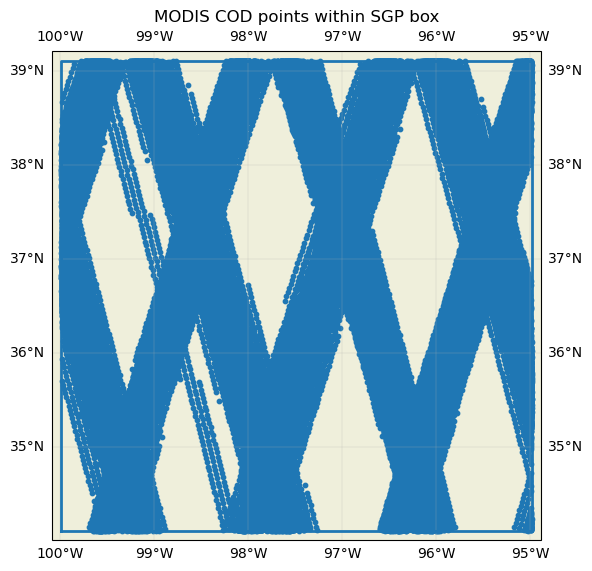

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ===== SGP box =====
sgp_lat_min, sgp_lat_max = 34.107322, 39.107322
sgp_lon_min, sgp_lon_max = -99.987643, -94.987643

# 取数据（确保是 numpy array）
lon = ds["lon"].values
lat = ds["lat"].values

# 可选：过滤掉 NaN
m = np.isfinite(lon) & np.isfinite(lat)
lon = lon[m]
lat = lat[m]

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6, 6), dpi=100)
ax = plt.axes(projection=proj)

# 地图范围（稍微留点边）
pad = 0.1
ax.set_extent([sgp_lon_min - pad, sgp_lon_max + pad,
               sgp_lat_min - pad, sgp_lat_max + pad], crs=proj)

# 底图要素
ax.add_feature(cfeature.LAND, linewidth=0)
ax.add_feature(cfeature.OCEAN, linewidth=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.6)

# 画散点
ax.scatter(lon, lat, s=10, transform=proj)

# 画 SGP box（红框）
box_lon = [sgp_lon_min, sgp_lon_max, sgp_lon_max, sgp_lon_min, sgp_lon_min]
box_lat = [sgp_lat_min, sgp_lat_min, sgp_lat_max, sgp_lat_max, sgp_lat_min]
ax.plot(box_lon, box_lat, transform=proj, linewidth=2)

ax.set_title("MODIS COD points within SGP box")
plt.tight_layout()
plt.show()
